In [1]:
from autoencoder import AutoEncoder,LSTMAutoEncoder
import json
from typing import List, Tuple
import numpy as np
import os
from dataset_utils import min_max_normalization, TimeSeriesAutoEncoderDataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from train_utils import Trainer
from eval_utils import Evaluator
import ruptures as rpt
rpt.detection.BottomUp
import matplotlib.pyplot as plt
from cusum import CusumMeanDetector


DATASET_PATH = "../dataset"
LTSF_ONLINE_RESULTS_PATH = "../ltsf/online_training/results"
LTSF_MODEL_NAME = "lstm"
LEN_WINDOW = 4

BATCH_SIZE = 1
TRAIN_EPOCH = 40
EARLY_STOP_GAIN = 0.01
EARLY_STOP_LOSS = 0.02

LR = 1e-1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [3]:
def read_result(file_name: str) -> np.ndarray:
    dir = os.path.join(LTSF_ONLINE_RESULTS_PATH, LTSF_MODEL_NAME)
    result = None
    with open(os.path.join(dir, file_name), "r") as f:
        result = json.load(f)
    result = np.array(result)
    return result

In [4]:
def get_gt_and_pd(workload_name: str, name_split: str, is_scaled: bool) -> Tuple[np.ndarray, np.ndarray]:
    gt_file_name = None
    if is_scaled:
        gt_file_name = workload_name+"_gt_"+name_split+"_"+"scaled.json"
    else:
        gt_file_name = workload_name+"_gt_"+name_split+"_"+"original.json"

    pd_file_name = None
    if is_scaled:
        pd_file_name = workload_name+"_pd_"+name_split+"_"+"scaled.json"
    else:
        pd_file_name = workload_name+"_pd_"+name_split+"_"+"original.json"

    gt = read_result(gt_file_name)
    pd = read_result(pd_file_name)
    
    gt_0=gt[:,:,0,:]
    pd_0=pd[:,:,0,:]
    return gt_0, pd_0

In [5]:
def learn_on_history(history_data: np.ndarray) -> AutoEncoder:
    train_set, train_scaler = min_max_normalization(history_data)
    train_dataset = TimeSeriesAutoEncoderDataset(train_set, LEN_WINDOW)
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = AutoEncoder(LEN_WINDOW, 1).to(DEVICE)
    # for name, param in model.named_parameters():
    #     if 'weight' in name:
    #         init.xavier_normal_(param)
    #     elif 'bias' in name:
    #         init.constant_(param, 0.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()
    trainer = Trainer(model, train_dataloader, loss_fn, optimizer, num_epochs=TRAIN_EPOCH, early_stop_gain=EARLY_STOP_GAIN, early_stop_loss=EARLY_STOP_LOSS, lr_scheduler=None, device=DEVICE)
    trainer.train_by_epoch()
    train_evaluator = Evaluator(model, train_dataloader, loss_fn, DEVICE)
    train_evaluator.evaluate()
    return model, train_evaluator.get_emb()

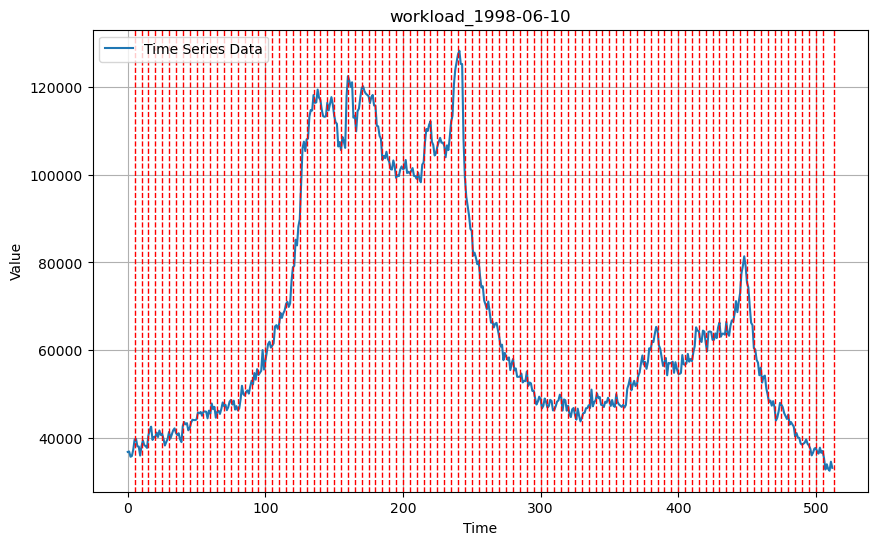

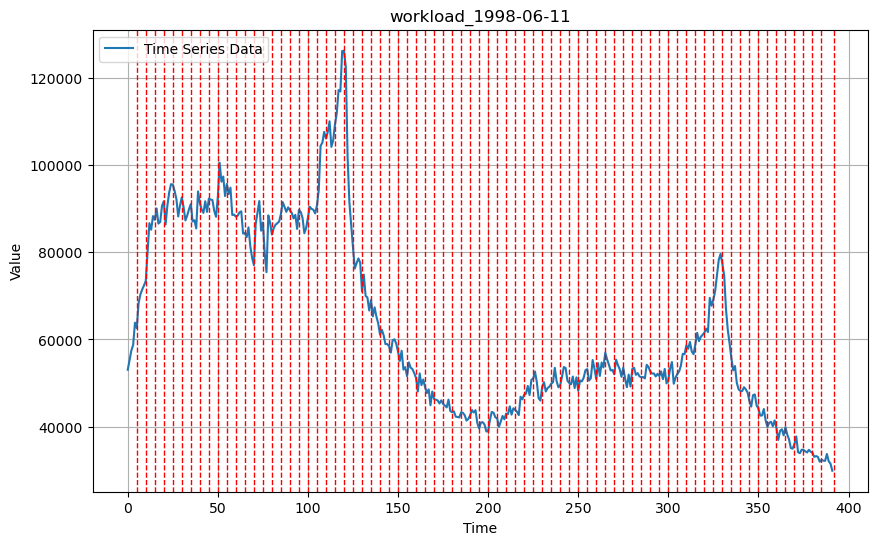

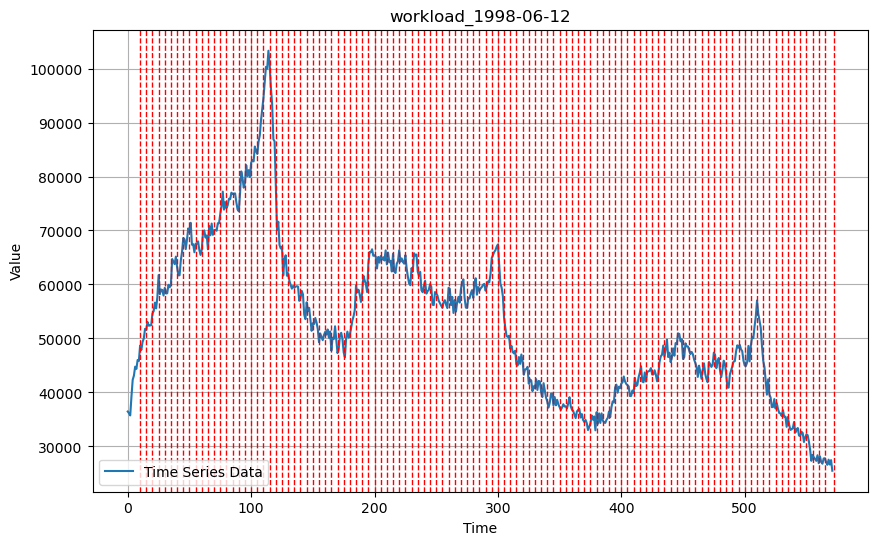

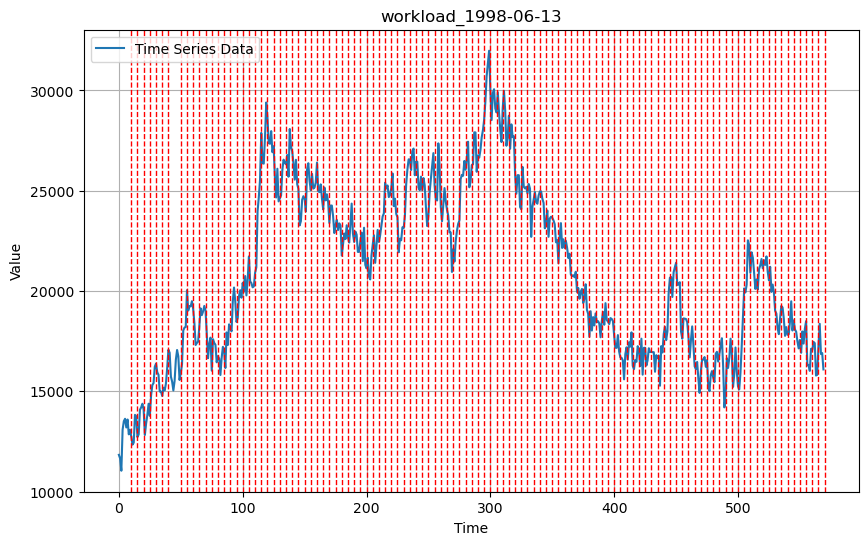

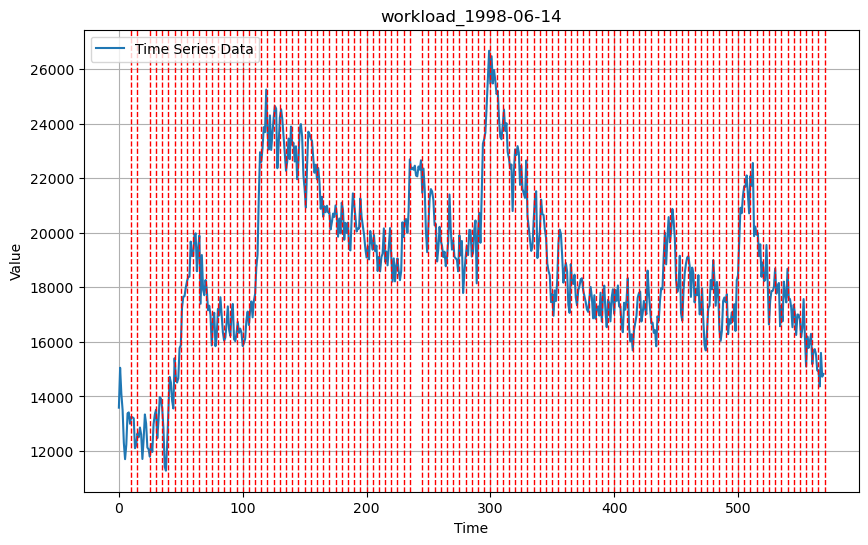

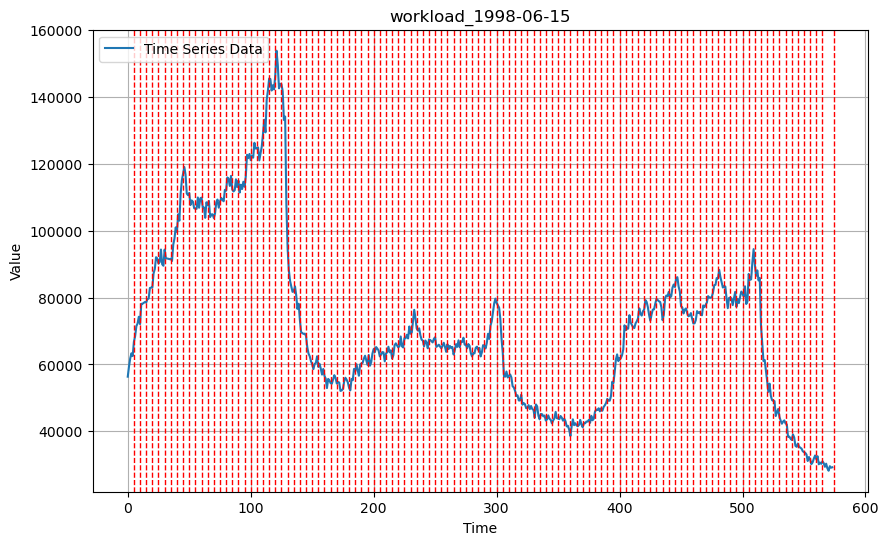

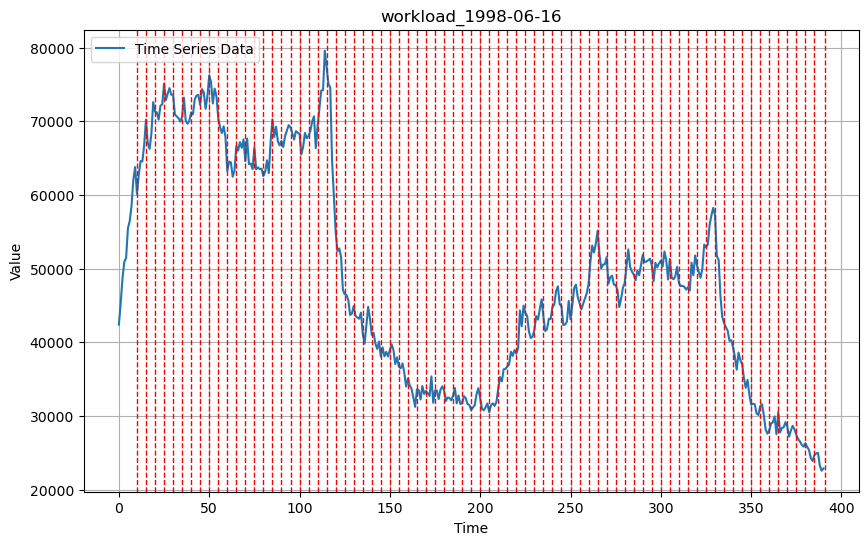

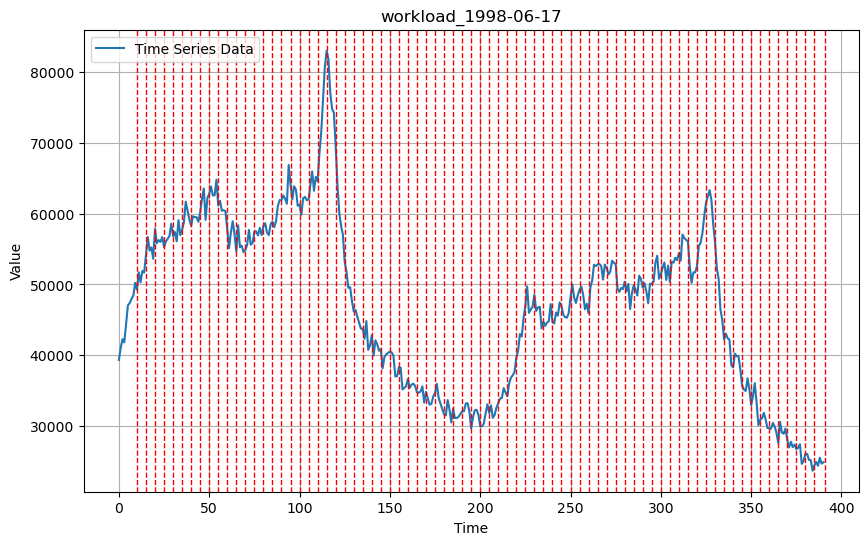

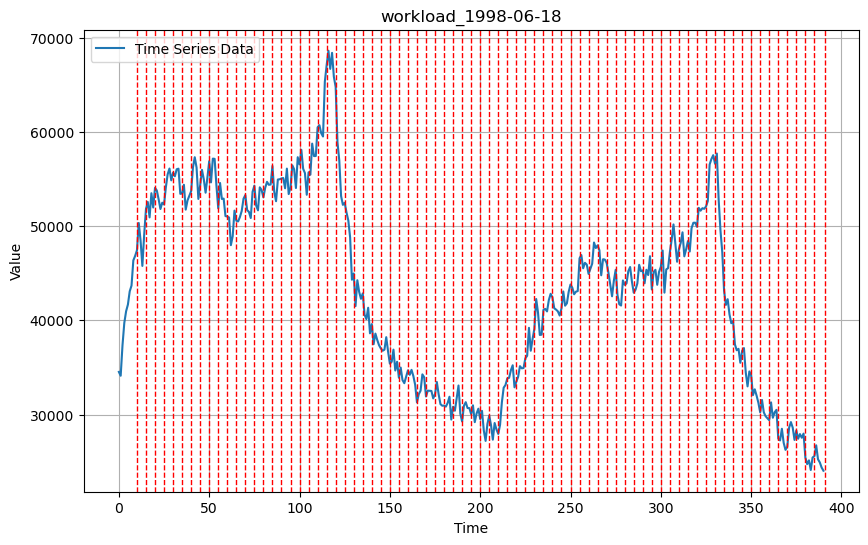

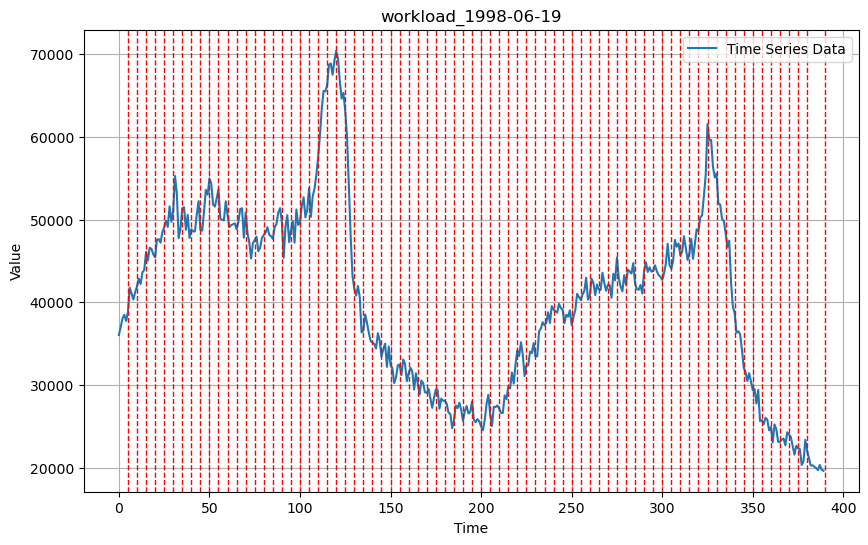

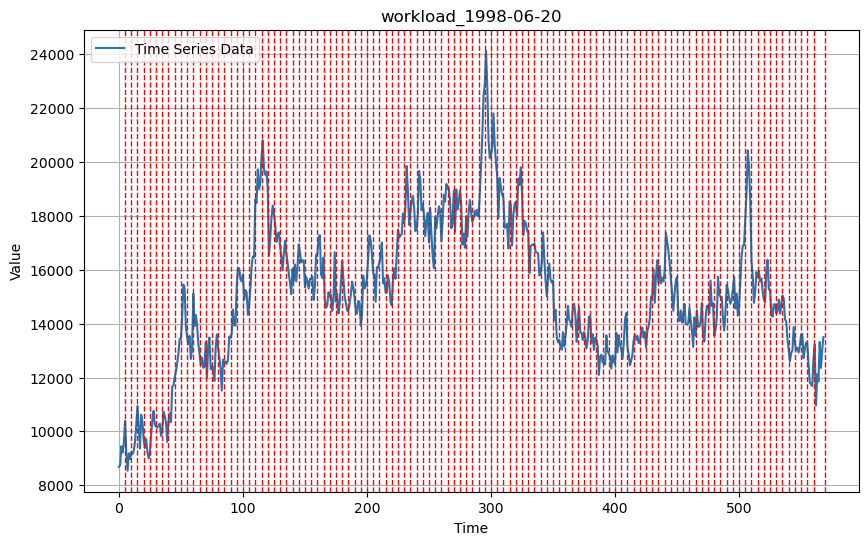

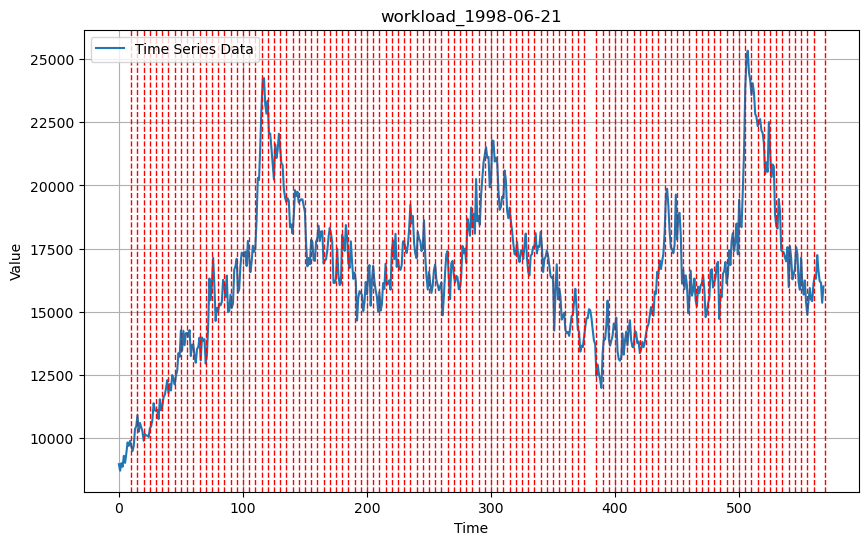

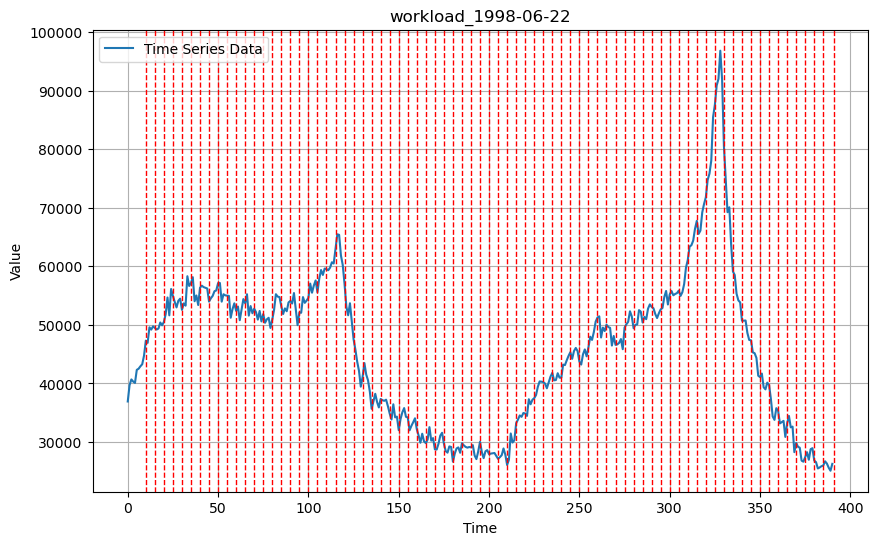

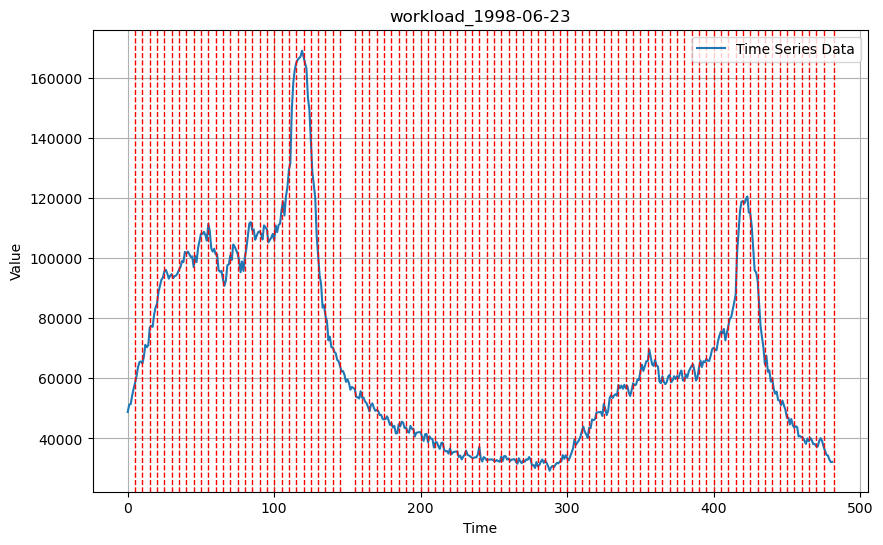

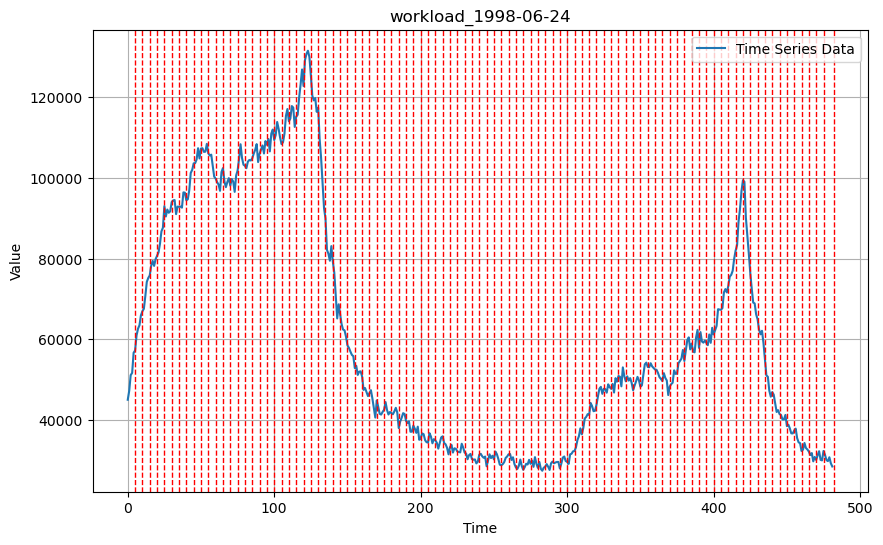

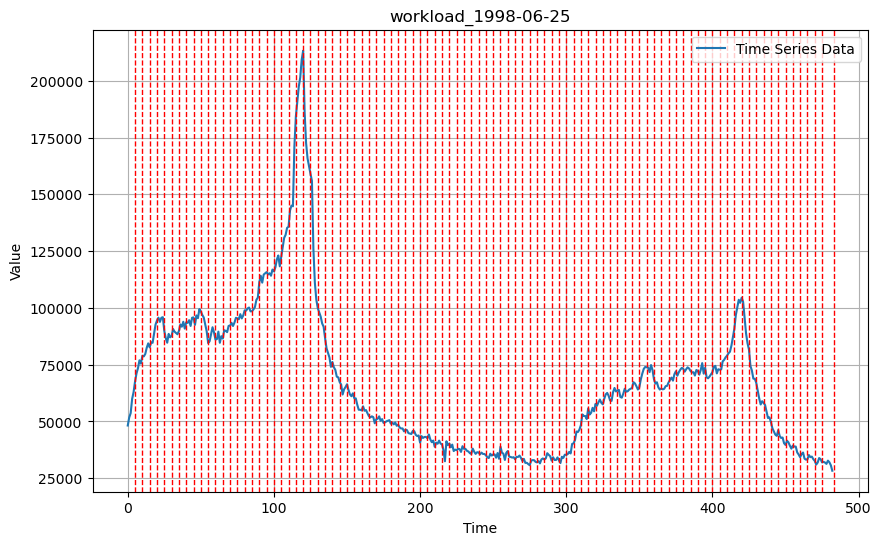

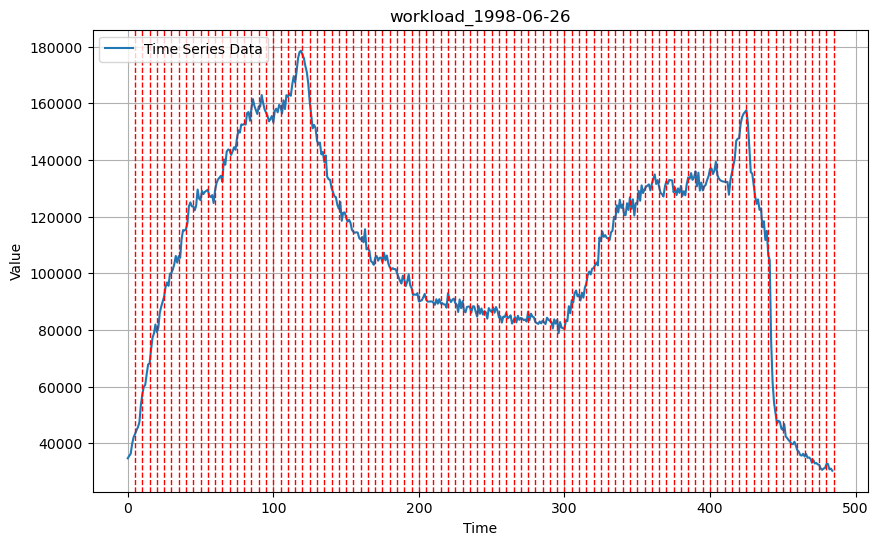

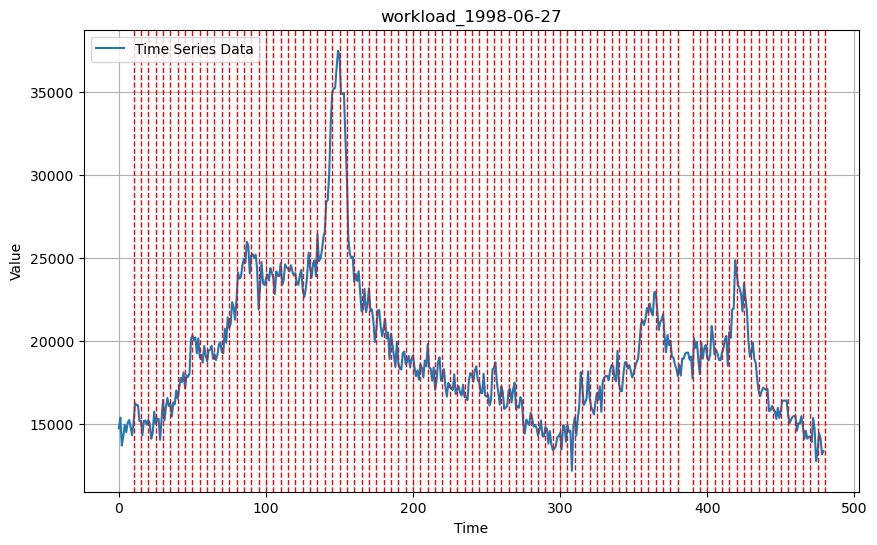

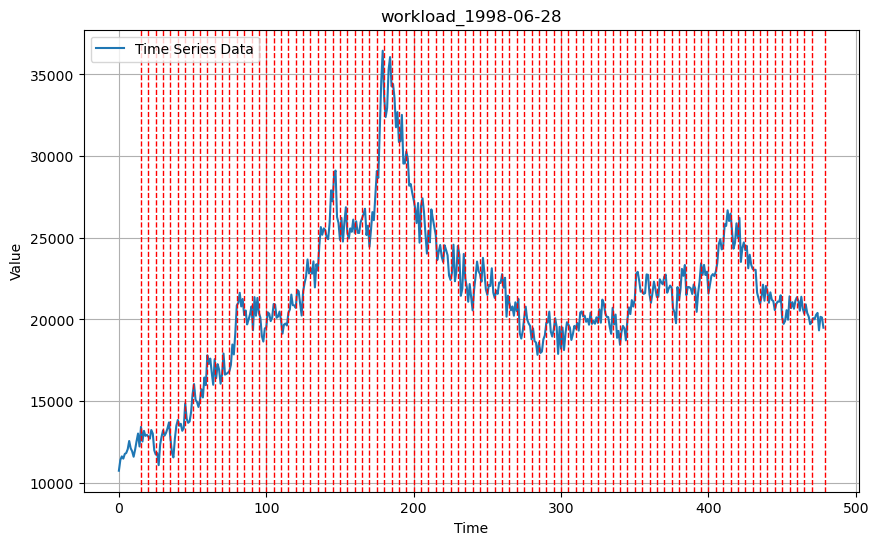

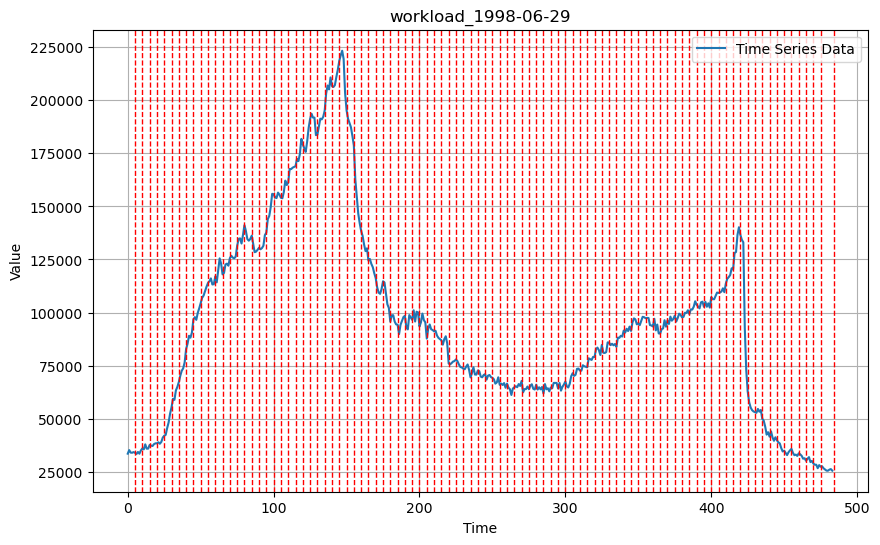

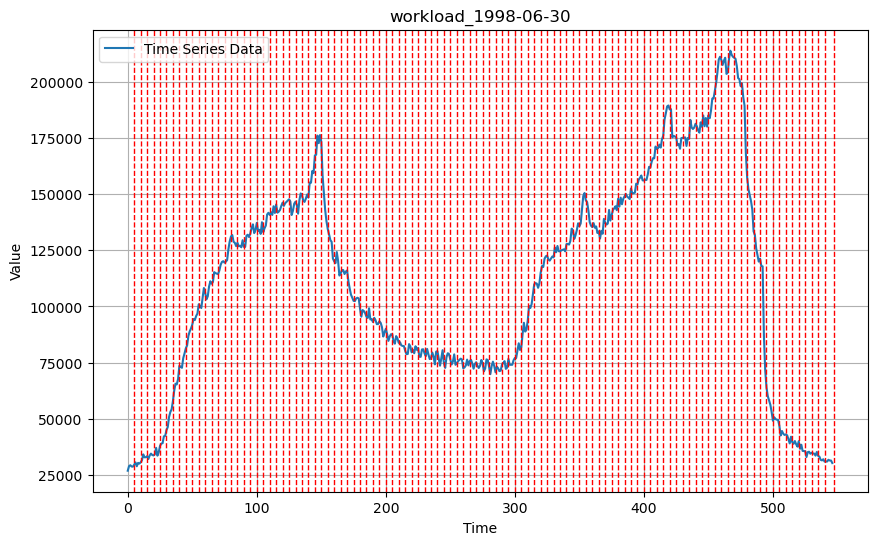

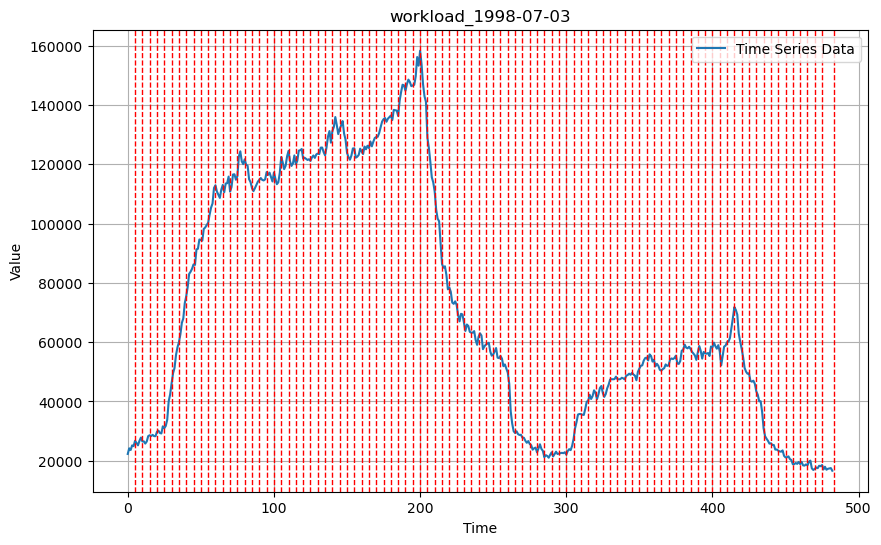

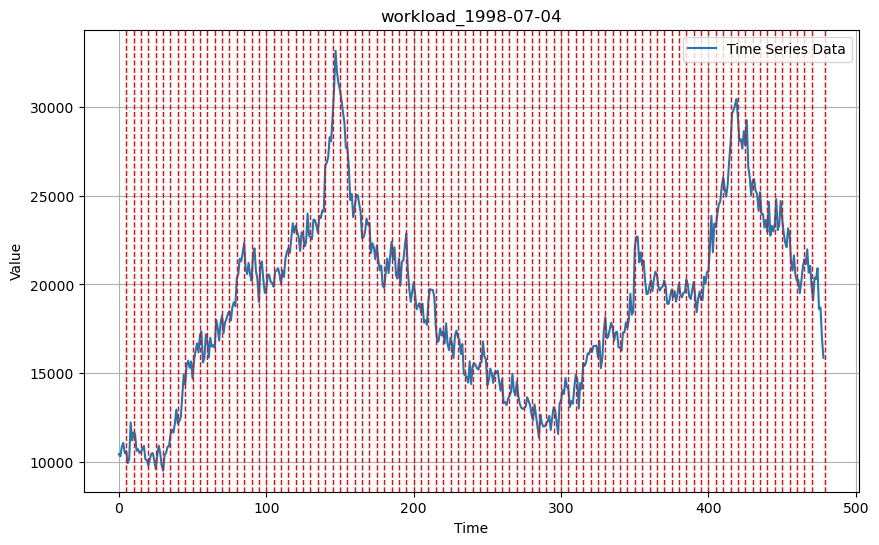

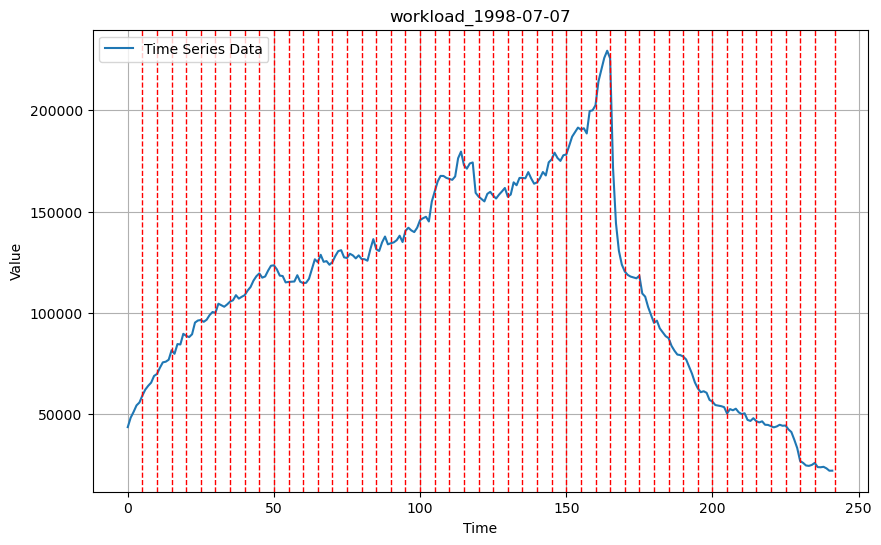

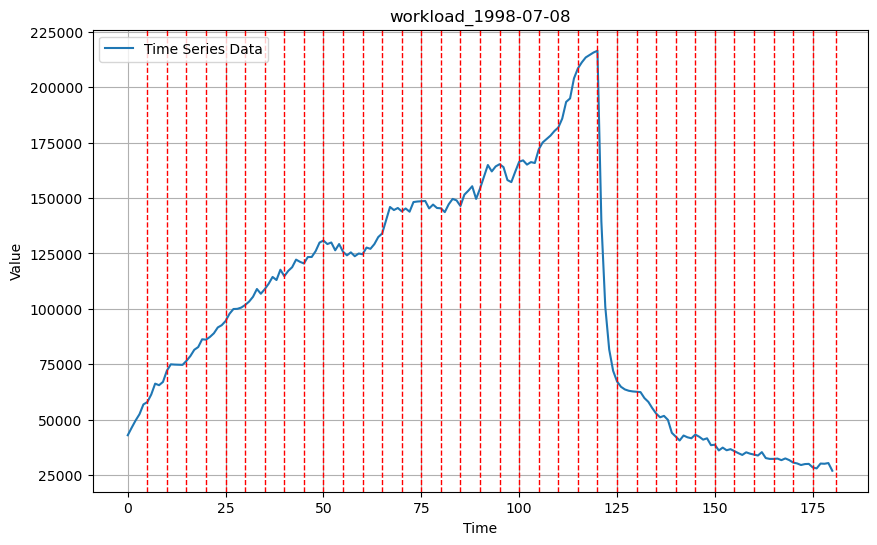

In [23]:
data_file_list = get_data_file_list(DATASET_PATH)
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    gt, pd = get_gt_and_pd(workload_name, "test", is_scaled=False)
    gt = np.squeeze(gt)
    algo = rpt.Binseg(model="ar",jump=5).fit(gt)
    result = algo.predict(epsilon=1e6)
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(gt)), gt, label='Time Series Data')
    for cp in result:
        plt.axvline(x=cp, color='red', linestyle='--', linewidth=1)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(workload_name)
    plt.legend()
    plt.grid(True)
    plt.show()